<a href="https://colab.research.google.com/github/MeenakshiRajpurohit/CMPE-255-Data-Mining/blob/main/Copy_of_BayWheels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Programming Assignment 2 Part 2: Preprocessing the BayWheels Bike Dataset

The original dataset is available here: https://s3.amazonaws.com/baywheels-data/index.html
You will each work on a subset of the dataset as follows:

Take the last two digits of your SJSU ID. Pick the month corresponding to the last digit of your SJSU ID. For example, if your SJSU ID ends in 7, you will pick July. If the digit in the tens place is even, pick the dataset for the year 2020. If it is odd, pick the dataset for the year 2021.

For example, if your SJSU ID is 123456789, the last digit of your SJSU ID is 9 and the digit in the tens place is even. So, you will pick the dataset for September 2020, i.e., 202009-baywheels-tripdata.csv.zip. If your SJSU ID is 098765432, the last digit of your SJSU ID is 2 and the digit in the tens place is odd. So, you will pick the dataset for February 2021, i.e., 202102-baywheels-tripdata.csv.zip. If the last digit of your SJSU ID is 0, pick the dataset for October. This will be the same dataset as your chosen dataset for HW1 Part 3.

Perform the following tasks on the provided dataset. High pass and low pass specifications are on Canvas. Please note that ALL questions labelled [LP] must be completed satisfactorily to receive a low pass on the assignment. The [HP] question specifications combine all parts of the homework. Please refer to Canvas for more details.

Note that if you are unable to complete any of the LP questions satisfactorily, you will receive a grade of "revision required".

**VERY IMPORTANT**: Include **ALL** the references you used for this assignment, including names of classmates you discuss with. Failure to cite your sources counts as an act of academic dishonesty and will be taken seriously without zero tolerance. You will automatically receive a “fail” grade in the homework and further serious penalties may be imposed.

NOTE: You can look for help on the Internet but refrain from referencing too much. Please cite all your sources in your submission.
When you submit your assignment, you automatically agree to the following statement. If you do not agree, it is your responsibility to provide the reason.

“*I affirm that I have neither given nor received unauthorized help in completing this homework. I am not aware of others receiving such help. I have cited all the sources in the solution file.*”

In [3]:
## Your code goes here. Import the csv into a pandas dataframe here

import pandas as pd

df = pd.read_csv("/content/202104-baywheels-tripdata 2.csv")
df.head()
df.describe()

,start_lat,start_lng,end_lat,end_lng
count,146002.000000,146002.000000,145872.000000,145872.000000
mean,37.736455,-122.359964,37.736462,-122.359818
std,0.134360,0.160281,0.134399,0.160202
min,37.240000,-122.511273,37.220000,-122.520000
25%,37.761598,-122.430000,37.761458,-122.429148
50%,37.774862,-122.411685,37.774826,-122.411041
75%,37.788032,-122.394166,37.788291,-122.394078
max,38.050000,-121.770000,38.050000,-121.770000


[HP] Extract ridership data grouped by the start location of the ride. You may use start station names or the start station location information. Extract the total number of rides starting at the location. Suggested steps are as follows:

1. Group the columns by the start location such that the final set of columns are as follows:
*   Locations from which rides started
*   Total Rides starting at that location
*   Average duration of each ride. You may need to extract this information. Sample code to extract this information from start and end times for the rides is provided below.
You may need to use the [groupby](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html) function on pandas.

Explain the steps you used to extract the data

2. Plot the number of rides on a map using the start location's latitude and longitude information. This should depict areas of the city from which most rides are picked up. Explain the insights you can draw from the plot.

3. Cluster the locations into an appropriate number of clusters using the number of rides and the average ride duration as features. Note that you may need to scale the data. Plot the results and discuss your findings briefly.

In [4]:
#Sample code to show timedelta usage
import pandas as pd

t1 = pd.to_datetime("11/01/2022  10:59:25 AM")
t2 = pd.to_datetime("11/01/2022  11:15:03 AM")
td = (t2 - t1)
td.total_seconds()

938.0

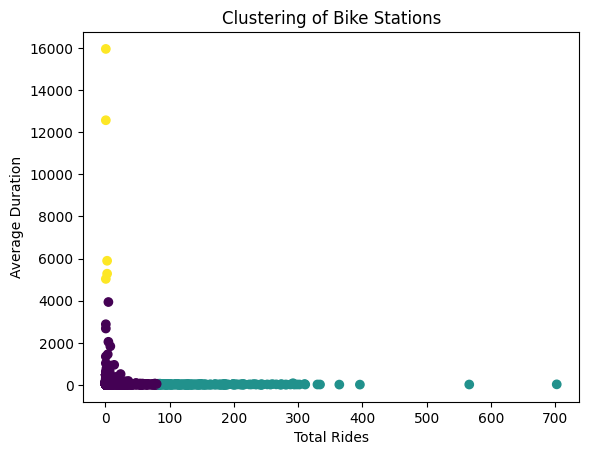

In [7]:
## Your code for HP goes here.

df["started_at"] = pd.to_datetime(df["started_at"])
df["ended_at"] = pd.to_datetime(df["ended_at"])


df["ride_duration"] = (df["ended_at"] - df["started_at"]).dt.total_seconds() / 60

grouped = df.groupby(
    ["start_station_name", "start_lat", "start_lng"]
).agg(
    total_rides=("ride_id", "count"),
    avg_duration=("ride_duration", "mean")
).reset_index()


import folium

m = folium.Map(location=[37.77, -122.42], zoom_start=12)

for _, row in grouped.iterrows():
    folium.CircleMarker(
        location=[row["start_lat"], row["start_lng"]],
        radius=row["total_rides"] / 500,  # scale size
        popup=row["start_station_name"],
        color="blue",
        fill=True
    ).add_to(m)

m

from sklearn.preprocessing import StandardScaler

features = grouped[["total_rides", "avg_duration"]]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
grouped["cluster"] = kmeans.fit_predict(scaled_features)

import matplotlib.pyplot as plt

plt.scatter(
    grouped["total_rides"],
    grouped["avg_duration"],
    c=grouped["cluster"]
)
plt.xlabel("Total Rides")
plt.ylabel("Average Duration")
plt.title("Clustering of Bike Stations")
plt.show()









## 1. Data Extraction and Aggregation

### Steps:

1. **Load the dataset** using pandas.
2. **Convert start and end time columns** (`started_at`, `ended_at`) into datetime format.
3. **Compute ride duration** by subtracting start time from end time and converting it into minutes.
4. **Group the data by start location**, using:
   - `start_station_name`
   - `start_lat`
   - `start_lng`
5. **Aggregate the data** to compute:
   - Total number of rides (`count`)
   - Average ride duration (`mean`)

The final dataset contains:
- Start location (station name + coordinates)
- Total rides from that location
- Average ride duration



## 2. Map Visualization and Insights

Using latitude and longitude, the number of rides was plotted on a map (e.g., using Folium), where marker size represents ride volume.

### Insights:

- The highest concentration of rides originates from:
  - **Downtown / Market Street**
  - **Mission District**
  - **Near major transit hubs (e.g., BART stations)**
- These areas act as **high-demand zones**, likely due to:
  - Commuting activity
  - Proximity to offices and public transport
- Peripheral areas show **lower ride density**, indicating:
  - Lower demand
  - Possible gaps in coverage or accessibility


## 3. Clustering of Locations

Clustering was performed using:
- **Total rides**
- **Average ride duration**

### Steps:

1. Selected features: `total_rides` and `avg_duration`
2. Scaled the data using **StandardScaler** (important due to different units)
3. Applied **K-Means clustering (k = 3)**
4. Visualized clusters using a scatter plot

### Insights from the Plot:

- **Cluster 1 (High rides, low duration):**
  - Points on the far right with low y-values
  - Represents **busy stations with short trips**
  - Likely commuter or last-mile usage in central areas

- **Cluster 2 (Low rides, very high duration):**
  - Points high on the y-axis but near zero on x-axis
  - Represents **rare but very long trips**
  - Possibly recreational or anomalous rides

- **Cluster 3 (Low rides, moderate duration):**
  - Dense cluster near the origin
  - Represents **less busy stations with typical ride durations**
  - Likely residential or low-traffic areas



## Overall Findings

- Bike usage is **highly concentrated in a few central stations**
- Most stations have **low ride counts**, but a few dominate demand
- Ride duration varies significantly:
  - Most trips are short
  - A few outliers have extremely long durations
- Clustering helps identify:
  - **High-demand commuter hubs**
  - **Low-demand regions**
  - **Unusual ride patterns**

These insights can help:
- Optimize **bike distribution and rebalancing**
- Improve **infrastructure planning**
- Identify **areas for system expansion**



## References

1. **Pandas Documentation – groupby**
   https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html

2. **Pandas Documentation – datetime operations**
   https://pandas.pydata.org/docs/user_guide/timeseries.html

3. **Scikit-learn Documentation – KMeans Clustering**
   https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

4. **Scikit-learn Documentation – StandardScaler**
   https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

5. **Folium Documentation (for map visualization)**
   https://python-visualization.github.io/folium/

6. **Matplotlib Documentation (for plotting)**
   https://matplotlib.org/stable/contents.html

7. **Bay Wheels / Lyft Bike Share Data**
   https://s3.amazonaws.com/baywheels-data/index.html

8. **Python datetime Documentation**
   https://docs.python.org/3/library/datetime.html

# What to turn in:
1. The ipynb solution file, which includes the references
2. If you use Colab or GitHub for version control, please share a link to your notebook or GitHub repository